# Identificação de Jatos de b com MLP e CNN

## Introdução

A identificação precisa de jatos originários da fragmentação de quarks *bottom* (conhecida como *b-tagging*) é uma das tarefas mais fundamentais em experimentos de física de altas energias, como os realizados no Large Hadron Collider (LHC). Essa técnica é essencial para a reconstrução de eventos que envolvem a produção de bósons de Higgs (H → bb̄), bem como para a busca de nova física além do Modelo Padrão.

Neste projeto, utilizamos dados abertos do experimento CMS (Compact Muon Solenoid), disponibilizados pelo CERN Open Data Portal (registro 12102). Os dados consistem em simulações Monte Carlo de eventos de colisões próton-próton a 13 TeV, contendo dois tipos de jatos:
- **Sinal (Hbb)**: jatos provenientes da decadência de um bóson de Higgs em um par bottom-antibottom.
- **Fundo (QCD)**: jatos produzidos por processos de Cromodinâmica Quântica (QCD), que constituem a principal fonte de ruído.

O objetivo principal deste trabalho é desenvolver e comparar dois modelos de aprendizado profundo para a classificação binária desses jatos:
1. **MLP (Multilayer Perceptron)**: uma rede neural totalmente conectada, que combina todas as variáveis de entrada de forma não-linear.
2. **CNN 1D (Rede Neural Convolucional Unidimensional)**: que trata as 27 variáveis físicas do jato como uma sequência temporal, aplicando filtros convolucionais para capturar correlações locais entre *features* adjacentes.

A métrica de avaliação escolhida é a Área Sob a Curva ROC (AUC), que mede a capacidade do modelo de distinguir entre as duas classes em diferentes limiares de decisão. Com este estudo, buscamos identificar qual arquitetura oferece o melhor compromisso entre poder preditivo e eficiência computacional, fornecendo *insights* práticos para aplicações em análises de dados do LHC.

### 1. Configuração e Importações

In [1]:
import os
import json
import numpy as np
import tables
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

2026-07-27 18:45:20.197009: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-27 18:45:24.267036: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Download dos Arquivos HDF5 diretamente do EOS

Os arquivos estão disponíveis em:
- **Teste**: `http://opendata.cern.ch/eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/test/ntuple_merged_0.h5`
- **Treino**: `http://opendata.cern.ch/eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/train/ntuple_merged_<i>.h5` com i=9, 10


Os links acima funcionam somente para download das amostras pelo código. A página da web se encontra no link: `https://opendata.cern.ch/record/12102`



In [13]:
# ====== PARÂMETROS EDITÁVEIS ======
N_TRAIN_FILES = 2   # número de arquivos de treino para baixar (começando do índice 9)
N_TEST_FILES  = 1   # número de arquivos de teste para baixar (começando do índice 0)
MAX_SAMPLES_PER_FILE = None  # None para carregar tudo
# ==================================

# Criar diretórios
os.makedirs('train', exist_ok=True)
os.makedirs('test', exist_ok=True)

def download_file(url, dest_path):
    if not os.path.exists(dest_path):
        print(f"Baixando {url} -> {dest_path}")
        !wget -q {url} -O {dest_path}
        print("Download concluído.")
    else:
        print(f"Arquivo {dest_path} já existe, pulando.")

base_test = "http://opendata.cern.ch/eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/test/"
base_train = "http://opendata.cern.ch/eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/train/"

# Baixar arquivos de teste (índices 0 a N_TEST_FILES-1)
for i in range(N_TEST_FILES):
    filename = f"ntuple_merged_{i}.h5"
    url = base_test + filename
    dest = os.path.join('test', filename)
    download_file(url, dest)

# Baixar arquivos de treino (índices 9 a 9+N_TRAIN_FILES-1)
for i in range(9, 9 + N_TRAIN_FILES):
    filename = f"ntuple_merged_{i}.h5"
    url = base_train + filename
    dest = os.path.join('train', filename)
    download_file(url, dest)

print("Download concluído.")

Arquivo test/ntuple_merged_0.h5 já existe, pulando.
Arquivo train/ntuple_merged_9.h5 já existe, pulando.
Arquivo train/ntuple_merged_10.h5 já existe, pulando.
Download concluído.


### 3. Carregamento e Preparação dos Dados
 
#### Vamos carregar os arquivos HDF5, extrair as features e as labels. As features utilizadas são as mesmas do notebook de referência do CERN, totalizando 27 variáveis. Também aplicaremos um corte na massa e no `pT` do jato para selecionar a região de interesse, como feito no exemplo oficial.

#### As labels são:
- `fj_isQCD * sample_isQCD`: indica se o jato é de QCD (fundo).
- `fj_isH * fj_isBB`: indica se o jato é de Hbb (sinal).

#### Para a classificação binária, usaremos apenas a label de sinal (Hbb).

In [15]:
# Lista das 27 features (mesmas do notebook oficial)
features = [
    'fj_jetNTracks', 'fj_nSV',
    'fj_tau0_trackEtaRel_0', 'fj_tau0_trackEtaRel_1', 'fj_tau0_trackEtaRel_2',
    'fj_tau1_trackEtaRel_0', 'fj_tau1_trackEtaRel_1', 'fj_tau1_trackEtaRel_2',
    'fj_tau_flightDistance2dSig_0', 'fj_tau_flightDistance2dSig_1',
    'fj_tau_vertexDeltaR_0', 'fj_tau_vertexEnergyRatio_0', 'fj_tau_vertexEnergyRatio_1',
    'fj_tau_vertexMass_0', 'fj_tau_vertexMass_1',
    'fj_trackSip2dSigAboveBottom_0', 'fj_trackSip2dSigAboveBottom_1',
    'fj_trackSip2dSigAboveCharm_0', 'fj_trackSipdSig_0',
    'fj_trackSipdSig_0_0', 'fj_trackSipdSig_0_1', 'fj_trackSipdSig_1',
    'fj_trackSipdSig_1_0', 'fj_trackSipdSig_1_1', 'fj_trackSipdSig_2',
    'fj_trackSipdSig_3', 'fj_z_ratio'
]

# Features espectadoras (usadas para aplicar cortes)
spectators = ['fj_sdmass', 'fj_pt']

# Labels
labels = ['fj_isQCD*sample_isQCD', 'fj_isH*fj_isBB']

nfeatures = len(features)
nlabels = len(labels)

def load_h5_file(filepath):
    """
    Carrega um arquivo HDF5 e retorna arrays de features e labels.
    Aplica cortes de massa e pT.
    """
    with tables.open_file(filepath, 'r') as h5file:
        njets = getattr(h5file.root, features[0]).shape[0]
        
        # Alocar arrays
        feature_array = np.zeros((njets, nfeatures))
        spec_array = np.zeros((njets, len(spectators)))
        label_array = np.zeros((njets, nlabels))
        
        # Carregar features
        for i, feat in enumerate(features):
            feature_array[:, i] = getattr(h5file.root, feat)[:]
        
        # Carregar espectadores
        for i, spec in enumerate(spectators):
            spec_array[:, i] = getattr(h5file.root, spec)[:]
        
        # Carregar labels
        for i, label_expr in enumerate(labels):
            prod0, prod1 = label_expr.split('*')
            fact0 = getattr(h5file.root, prod0)[:]
            fact1 = getattr(h5file.root, prod1)[:]
            label_array[:, i] = np.multiply(fact0, fact1)
    
    # Aplicar cortes: 40 < massa < 200 GeV e 300 < pT < 2000 GeV
    mass_cut = (spec_array[:, 0] > 40) & (spec_array[:, 0] < 200)
    pt_cut = (spec_array[:, 1] > 300) & (spec_array[:, 1] < 2000)
    mask = mass_cut & pt_cut
    
    feature_array = feature_array[mask]
    label_array = label_array[mask]
    
    # Manter apenas eventos com exatamente uma label (sinal ou fundo)
    label_sum = np.sum(label_array, axis=1)
    mask_single = label_sum == 1
    feature_array = feature_array[mask_single]
    label_array = label_array[mask_single]
    
    return feature_array, label_array

# Carregar todos os arquivos de treino
train_files = [os.path.join('train', f) for f in os.listdir('train') if f.endswith('.h5')]
X_train_list = []
y_train_list = []

for file in train_files:
    print(f"Carregando {file}...")
    X, y = load_h5_file(file)
    X_train_list.append(X)
    y_train_list.append(y)

X_train = np.vstack(X_train_list)
y_train = np.vstack(y_train_list)

print(f"Dados de treino carregados: {X_train.shape[0]} amostras.")

# Carregar todos os arquivos de teste
test_files = [os.path.join('test', f) for f in os.listdir('test') if f.endswith('.h5')]
X_test_list = []
y_test_list = []

for file in test_files:
    print(f"Carregando {file}...")
    X, y = load_h5_file(file)
    X_test_list.append(X)
    y_test_list.append(y)

X_test = np.vstack(X_test_list)
y_test = np.vstack(y_test_list)

print(f"Dados de teste carregados: {X_test.shape[0]} amostras.")

# Usar apenas a label de sinal (Hbb) para classificação binária
y_train = y_train[:, 1]  # índice 1 = Hbb
y_test = y_test[:, 1]

Carregando train/ntuple_merged_10.h5...
Carregando train/ntuple_merged_9.h5...
Dados de treino carregados: 125493 amostras.
Carregando test/ntuple_merged_0.h5...
Dados de teste carregados: 62991 amostras.


## 4. Pré-processamento

- Normalização dos dados (média zero e variância unitária) usando `StandardScaler`.
- Divisão do conjunto de treino em treino e validação (80/20).

In [16]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dividir treino em treino/validação
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Treino: {X_train_final.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test_scaled.shape[0]} amostras")

Treino: 100394 amostras
Validação: 25099 amostras
Teste: 62991 amostras


### 5. Análise Exploratória das Features
 
#### Vamos visualizar a distribuição das 27 variáveis físicas utilizadas para classificação. Para cada *feature*, plotamos um histograma separando as classes (Hbb vs QCD) para avaliar seu poder discriminante.


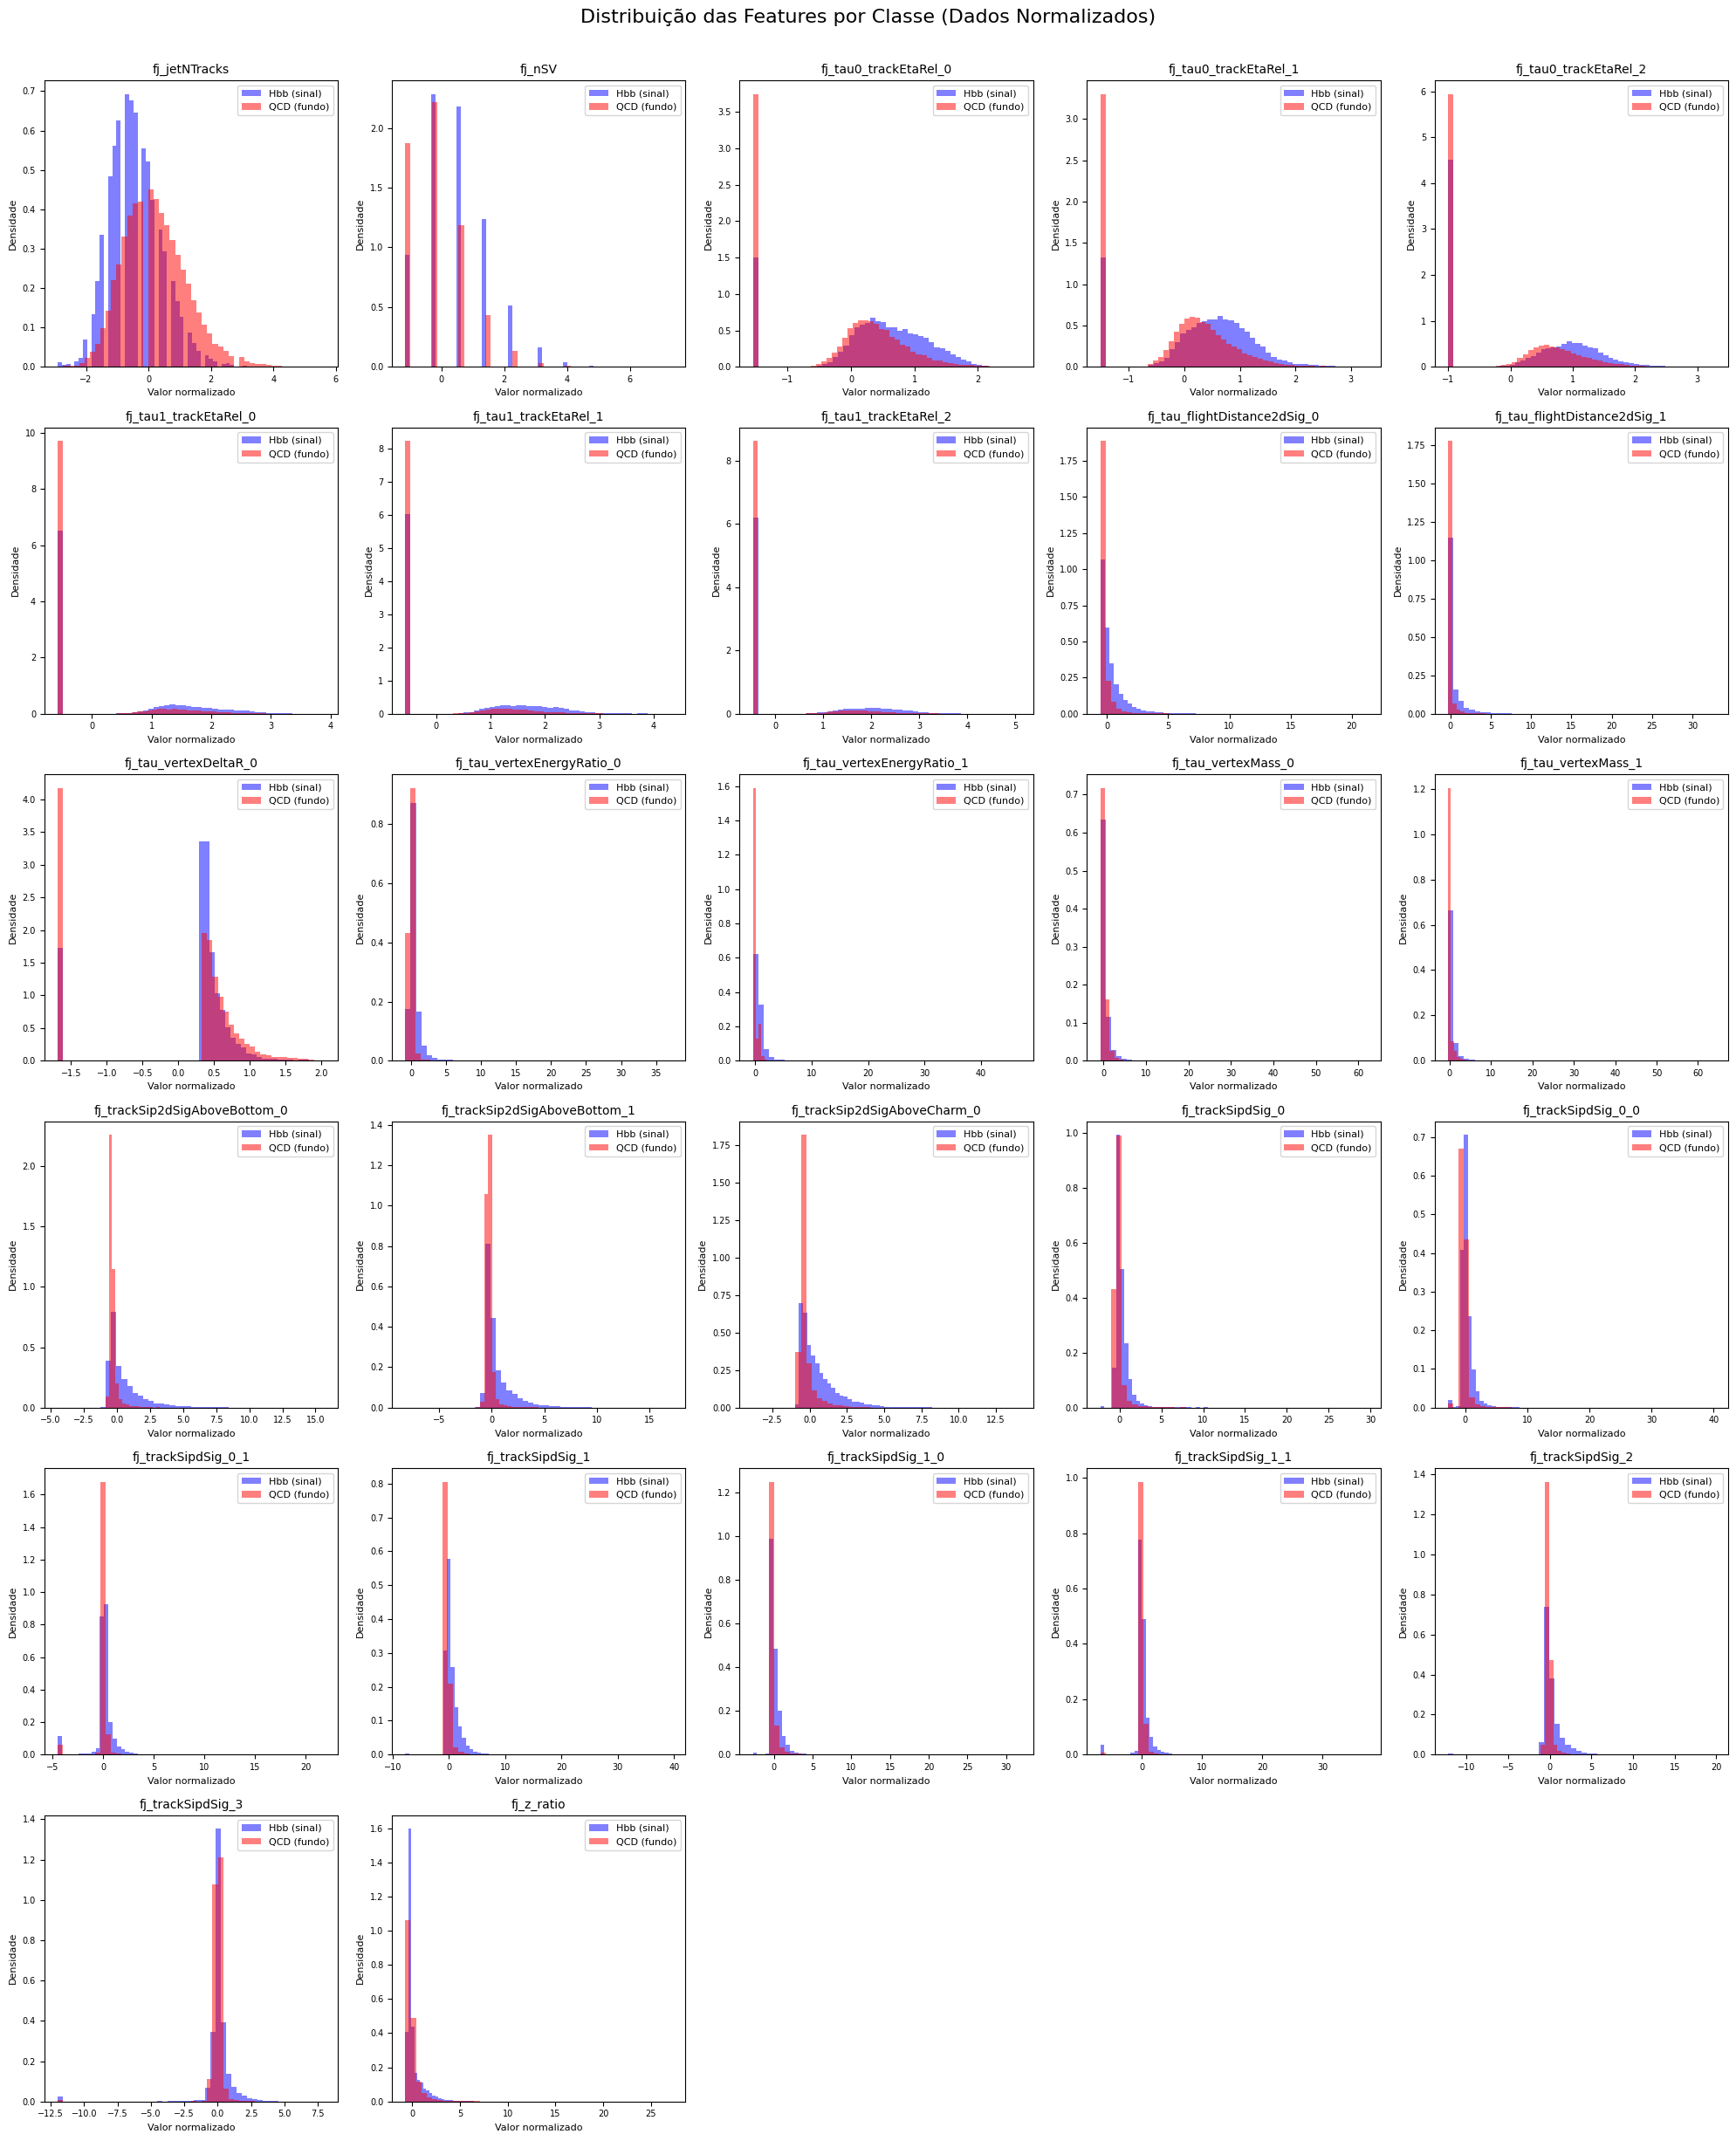

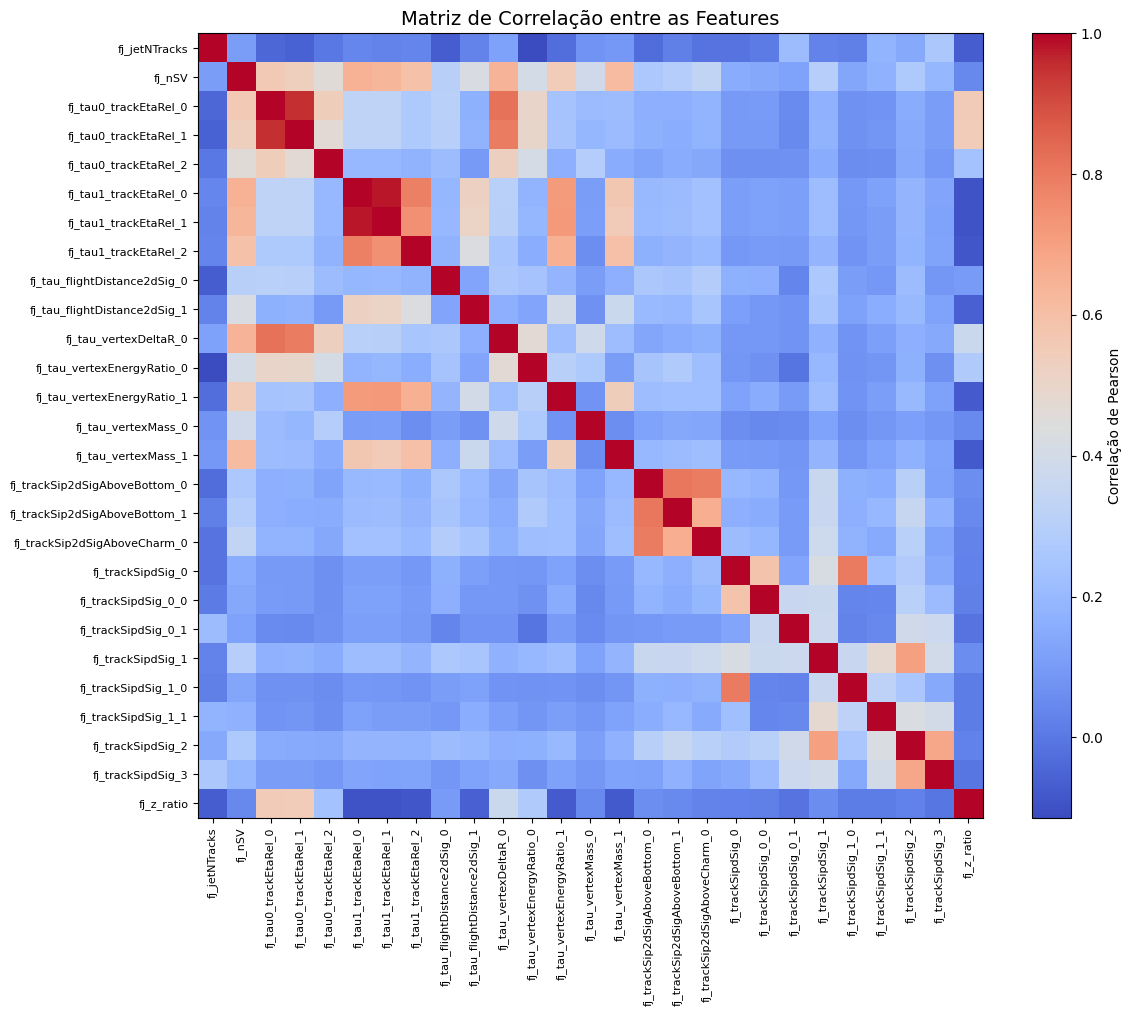

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Selecionar um subconjunto de amostras para plotagem
sample_size = min(50000, X_train_final.shape[0])
indices = np.random.choice(X_train_final.shape[0], sample_size, replace=False)
X_plot = X_train_final[indices]
y_plot = y_train_final[indices]

# Nomes legenda
feature_names = features

# Definir número de colunas para os subplots
n_features = len(feature_names)
cols = 5
rows = int(np.ceil(n_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(feature_names, axes)):
    # Separar por classe
    data_hbb = X_plot[y_plot == 1, i]
    data_qcd = X_plot[y_plot == 0, i]
    
    # Plotar histogramas
    bins = 50
    ax.hist(data_hbb, bins=bins, alpha=0.5, label='Hbb (sinal)', color='blue', density=True)
    ax.hist(data_qcd, bins=bins, alpha=0.5, label='QCD (fundo)', color='red', density=True)
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Valor normalizado', fontsize=8)
    ax.set_ylabel('Densidade', fontsize=8)
    ax.tick_params(labelsize=7)

# Remover subplots vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuição das Features por Classe (Dados Normalizados)', y=1.02, fontsize=16)
plt.show()

# Matriz de correlação
if X_plot.shape[0] > 5000:
    X_corr = X_plot[:5000]
else:
    X_corr = X_plot

corr_matrix = np.corrcoef(X_corr.T)
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlação de Pearson')
plt.title('Matriz de Correlação entre as Features', fontsize=14)
plt.xticks(np.arange(n_features), feature_names, rotation=90, fontsize=8)
plt.yticks(np.arange(n_features), feature_names, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Modelo MLP (Multilayer Perceptron)

In [17]:
def build_mlp(input_dim):
    inputs = Input(shape=(input_dim,), name='input')
    x = BatchNormalization(name='bn_1')(inputs)
    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu', name='dense_2')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu', name='dense_3')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

mlp_model = build_mlp(nfeatures)
mlp_model.summary()


checkpoint_mlp = ModelCheckpoint('mlp_best.h5', monitor='val_loss', save_best_only=True)
early_stop_mlp = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_mlp = mlp_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=1024,
    callbacks=[checkpoint_mlp, early_stop_mlp],
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 27)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,069 (19.80 KB)

 Trainable params: 5,015 (19.59 KB)

 Non-trainable params: 54 (216.00 B)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8552 - loss: 0.3478 - val_accuracy: 0.8580 - val_loss: 0.3349
Epoch 66/100
94/99 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8575 - loss: 0.3442

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8569 - loss: 0.3468 - val_accuracy: 0.8594 - val_loss: 0.3346
Epoch 67/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8558 - loss: 0.3472 - val_accuracy: 0.8583 - val_loss: 0.3351
Epoch 68/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8568 - loss: 0.3468 - val_accuracy: 0.8588 - val_loss: 0.3351
Epoch 69/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8560 - loss: 0.3471 - val_accuracy: 0.8598 - val_loss: 0.3357
Epoch 70/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8559 - loss: 0.3469 - val_accuracy: 0.8576 - val_loss: 0.3359
Epoch 71/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8559 - loss: 0.3474 - val_accuracy: 0.8589 - val_loss: 0.3349
Epoch 72/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8557 - loss: 0.3473 - val_accuracy: 0.8593 - val_loss: 0.3347
Epoch 73/100
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8556 - loss: 0.3492

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8563 - loss: 0.3465 - val_accuracy: 0.8603 - val_loss: 0.3340
Epoch 74/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8561 - loss: 0.3462 - val_accuracy: 0.8593 - val_loss: 0.3352
Epoch 75/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8558 - loss: 0.3472 - val_accuracy: 0.8594 - val_loss: 0.3347
Epoch 76/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8566 - loss: 0.3452 - val_accuracy: 0.8605 - val_loss: 0.3343
Epoch 77/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8563 - loss: 0.3464 - val_accuracy: 0.8604 - val_loss: 0.3347
Epoch 78/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8567 - loss: 0.3454 - val_accuracy: 0.8600 - val_loss: 0.3341
Epoch 79/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8567 - loss: 0.3458 - val_accuracy: 0.8581 - val_loss: 0.3352
Epoch 80/100
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8562 - loss: 0.3446

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8558 - loss: 0.3450 - val_accuracy: 0.8600 - val_loss: 0.3340
Epoch 81/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8572 - loss: 0.3460 - val_accuracy: 0.8591 - val_loss: 0.3345
Epoch 82/100
95/99 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8581 - loss: 0.3429

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8571 - loss: 0.3453 - val_accuracy: 0.8601 - val_loss: 0.3338
Epoch 83/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8569 - loss: 0.3469 - val_accuracy: 0.8600 - val_loss: 0.3342
Epoch 84/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8565 - loss: 0.3470 - val_accuracy: 0.8586 - val_loss: 0.3351
Epoch 85/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8569 - loss: 0.3462 - val_accuracy: 0.8600 - val_loss: 0.3351
Epoch 86/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8568 - loss: 0.3463 - val_accuracy: 0.8590 - val_loss: 0.3356
Epoch 87/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8563 - loss: 0.3466 - val_accuracy: 0.8597 - val_loss: 0.3342
Epoch 88/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8568 - loss: 0.3451 - val_accuracy: 0.8597 - val_loss: 0.3342
Epoch 89/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8579 - loss: 0.3443 - val_accuracy: 0.8592 - val_lo

## 7. Modelo CNN 1D

In [18]:
def build_cnn(input_dim):
    inputs = Input(shape=(input_dim, 1), name='input')
    
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

X_train_cnn = X_train_final.reshape(-1, nfeatures, 1)
X_val_cnn = X_val.reshape(-1, nfeatures, 1)
X_test_cnn = X_test_scaled.reshape(-1, nfeatures, 1)

cnn_model = build_cnn(nfeatures)
cnn_model.summary()

checkpoint_cnn = ModelCheckpoint('cnn_best.h5', monitor='val_loss', save_best_only=True)
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_final,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=1024,
    callbacks=[checkpoint_cnn, early_stop_cnn],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 27, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 27, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 27, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 13, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,473 (130.75 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 192 (768.00 B)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8615 - loss: 0.3373 - val_accuracy: 0.8601 - val_loss: 0.3319
Epoch 16/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8620 - loss: 0.3365 - val_accuracy: 0.8585 - val_loss: 0.3370
Epoch 17/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8623 - loss: 0.3359 - val_accuracy: 0.8616 - val_loss: 0.3322
Epoch 18/100
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8617 - loss: 0.3350

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8635 - loss: 0.3344 - val_accuracy: 0.8618 - val_loss: 0.3314
Epoch 19/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8624 - loss: 0.3349 - val_accuracy: 0.8604 - val_loss: 0.3336
Epoch 20/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8636 - loss: 0.3342 - val_accuracy: 0.8604 - val_loss: 0.3320
Epoch 21/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8633 - loss: 0.3326 - val_accuracy: 0.8607 - val_loss: 0.3331
Epoch 22/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8643 - loss: 0.3327 - val_accuracy: 0.8601 - val_loss: 0.3318
Epoch 23/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8643 - loss: 0.3320 - val_accuracy: 0.8604 - val_loss: 0.3335
Epoch 24/100
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8665 - loss: 0.3309

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8650 - loss: 0.3309 - val_accuracy: 0.8613 - val_loss: 0.3309
Epoch 25/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8646 - loss: 0.3291 - val_accuracy: 0.8603 - val_loss: 0.3314
Epoch 26/100
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8641 - loss: 0.3322

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8647 - loss: 0.3298 - val_accuracy: 0.8611 - val_loss: 0.3307
Epoch 27/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8656 - loss: 0.3289 - val_accuracy: 0.8609 - val_loss: 0.3310
Epoch 28/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8659 - loss: 0.3286 - val_accuracy: 0.8611 - val_loss: 0.3320
Epoch 29/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8661 - loss: 0.3284 - val_accuracy: 0.8608 - val_loss: 0.3316
Epoch 30/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8654 - loss: 0.3267 - val_accuracy: 0.8606 - val_loss: 0.3336
Epoch 31/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8661 - loss: 0.3279 - val_accuracy: 0.8610 - val_loss: 0.3313
Epoch 32/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8667 - loss: 0.3250 - val_accuracy: 0.8601 - val_loss: 0.3308
Epoch 33/100
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8663 - loss: 0.3266

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8672 - loss: 0.3255 - val_accuracy: 0.8625 - val_loss: 0.3293
Epoch 34/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8675 - loss: 0.3239 - val_accuracy: 0.8606 - val_loss: 0.3341
Epoch 35/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8665 - loss: 0.3260 - val_accuracy: 0.8623 - val_loss: 0.3307
Epoch 36/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8678 - loss: 0.3245 - val_accuracy: 0.8612 - val_loss: 0.3322
Epoch 37/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8690 - loss: 0.3222 - val_accuracy: 0.8609 - val_loss: 0.3320
Epoch 38/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8690 - loss: 0.3224 - val_accuracy: 0.8608 - val_loss: 0.3316
Epoch 39/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8687 - loss: 0.3217 - val_accuracy: 0.8605 - val_loss: 0.3321
Epoch 40/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8692 - loss: 0.3216 - val_accuracy: 0.8599 

### 8. Análise das Curvas de Perda (Loss) durante o Treinamento
 
#### Acompanhar a evolução da função de perda (*loss*) ao longo das épocas é fundamental para avaliar a convergência dos modelos e detectar possíveis problemas como *overfitting* ou *underfitting*.

#### Plotamos abaixo a perda de treino e de validação para ambos os modelos (MLP e CNN 1D). Idealmente, ambas as curvas devem diminuir e estabilizar. Se a perda de validação começar a aumentar enquanto a de treino continua caindo, isso indica *overfitting*.

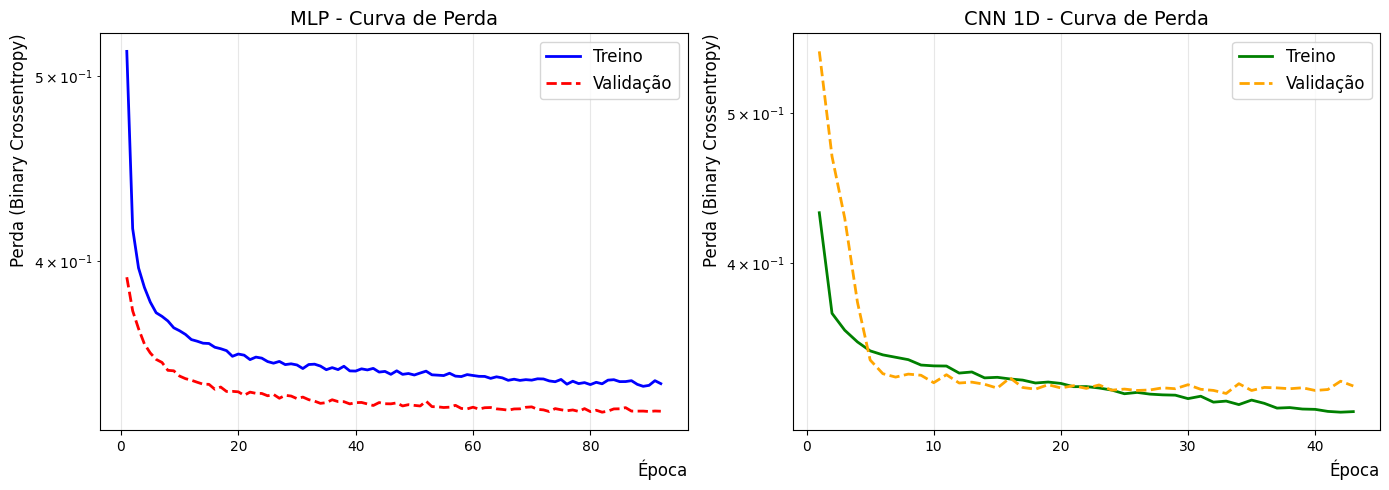

RESUMO DAS PERDAS
MLP:
  - Última perda de treino: 0.345405
  - Última perda de validação: 0.334150
  - Melhor perda de validação: 0.333765 (época 82)

CNN 1D:
  - Última perda de treino: 0.320489
  - Última perda de validação: 0.332945
  - Melhor perda de validação: 0.329264 (época 33)


In [30]:
import matplotlib.pyplot as plt

# Criar figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ----- MLP -----
epochs_mlp = range(1, len(history_mlp.history['loss']) + 1)
ax1.plot(epochs_mlp, history_mlp.history['loss'], 'b-', label='Treino', linewidth=2)
ax1.plot(epochs_mlp, history_mlp.history['val_loss'], 'r--', label='Validação', linewidth=2)
ax1.set_title('MLP - Curva de Perda', fontsize=14)
ax1.set_xlabel('Época', fontsize=12, loc='right')
ax1.set_ylabel('Perda (Binary Crossentropy)', fontsize=12, loc='top')
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_yscale('log')

# ----- CNN 1D -----
epochs_cnn = range(1, len(history_cnn.history['loss']) + 1)
ax2.plot(epochs_cnn, history_cnn.history['loss'], 'g-', label='Treino', linewidth=2)
ax2.plot(epochs_cnn, history_cnn.history['val_loss'], 'orange', linestyle='--', label='Validação', linewidth=2)
ax2.set_title('CNN 1D - Curva de Perda', fontsize=14)
ax2.set_xlabel('Época', fontsize=12, loc='right')
ax2.set_ylabel('Perda (Binary Crossentropy)', fontsize=12, loc='top')
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('loss_curves_comparison.png', dpi=300)
plt.show()

# Exibir a última perda e a perda mínima de validação para cada modelo
print("=" * 50)
print("RESUMO DAS PERDAS")
print("=" * 50)

best_epoch_mlp = np.argmin(history_mlp.history['val_loss']) + 1
best_val_loss_mlp = np.min(history_mlp.history['val_loss'])
print(f"MLP:")
print(f"  - Última perda de treino: {history_mlp.history['loss'][-1]:.6f}")
print(f"  - Última perda de validação: {history_mlp.history['val_loss'][-1]:.6f}")
print(f"  - Melhor perda de validação: {best_val_loss_mlp:.6f} (época {best_epoch_mlp})")

best_epoch_cnn = np.argmin(history_cnn.history['val_loss']) + 1
best_val_loss_cnn = np.min(history_cnn.history['val_loss'])
print(f"\nCNN 1D:")
print(f"  - Última perda de treino: {history_cnn.history['loss'][-1]:.6f}")
print(f"  - Última perda de validação: {history_cnn.history['val_loss'][-1]:.6f}")
print(f"  - Melhor perda de validação: {best_val_loss_cnn:.6f} (época {best_epoch_cnn})")

### 8.1. Análise das Curvas de Acurácia (accuracy) durante o Treinamento

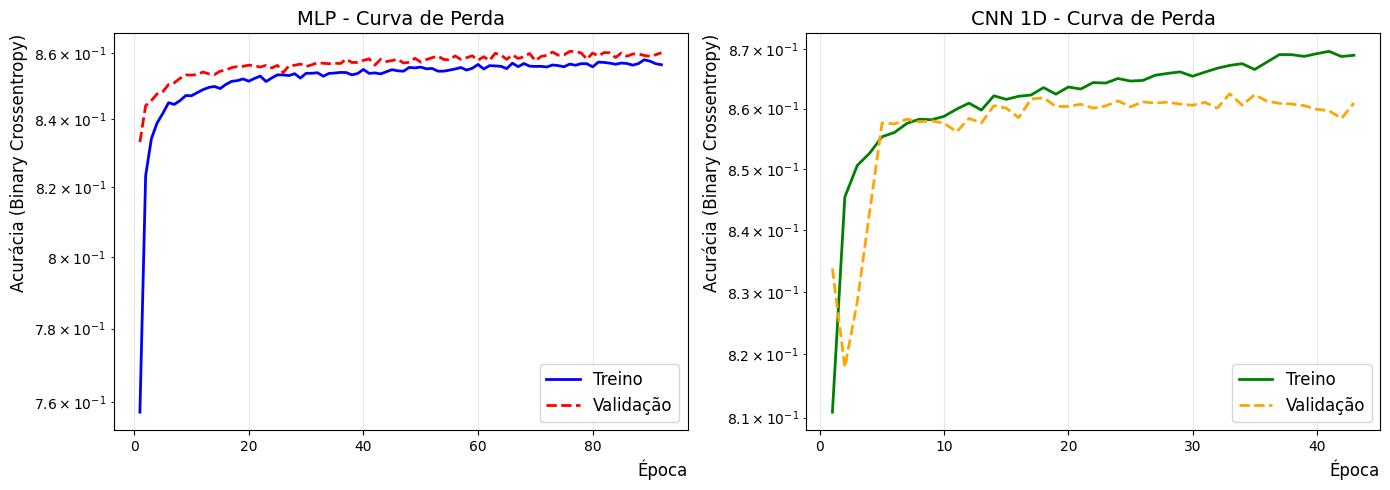

RESUMO DAS ACURÁCIAS
MLP:
  - Última acurácia de treino: 0.856406
  - Última acurácia de validação: 0.860074
  - Melhor acurácia de validação: 0.833260 (época 1)

CNN 1D:
  - Última acurácia de treino: 0.868926
  - Última acurácia de validação: 0.860911
  - Melhor acurácia de validação: 0.817921 (época 2)


In [29]:
import matplotlib.pyplot as plt

# Criar figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ----- MLP -----
epochs_mlp = range(1, len(history_mlp.history['accuracy']) + 1)
ax1.plot(epochs_mlp, history_mlp.history['accuracy'], 'b-', label='Treino', linewidth=2)
ax1.plot(epochs_mlp, history_mlp.history['val_accuracy'], 'r--', label='Validação', linewidth=2)
ax1.set_title('MLP - Curva de Perda', fontsize=14)
ax1.set_xlabel('Época', fontsize=12, loc='right')
ax1.set_ylabel('Acurácia (Binary Crossentropy)', fontsize=12, loc='top')
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_yscale('log')

# ----- CNN 1D -----
epochs_cnn = range(1, len(history_cnn.history['accuracy']) + 1)
ax2.plot(epochs_cnn, history_cnn.history['accuracy'], 'g-', label='Treino', linewidth=2)
ax2.plot(epochs_cnn, history_cnn.history['val_accuracy'], 'orange', linestyle='--', label='Validação', linewidth=2)
ax2.set_title('CNN 1D - Curva de Perda', fontsize=14)
ax2.set_xlabel('Época', fontsize=12, loc='right')
ax2.set_ylabel('Acurácia (Binary Crossentropy)', fontsize=12, loc='top')
ax2.legend(loc="lower right", fontsize=12)
ax2.grid(alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('acc_curves_comparison.png', dpi=300)
plt.show()

# Exibir a última perda e a perda mínima de validação para cada modelo
print("=" * 50)
print("RESUMO DAS ACURÁCIAS")
print("=" * 50)

best_epoch_mlp = np.argmin(history_mlp.history['val_accuracy']) + 1
best_val_loss_mlp = np.min(history_mlp.history['val_accuracy'])
print(f"MLP:")
print(f"  - Última acurácia de treino: {history_mlp.history['accuracy'][-1]:.6f}")
print(f"  - Última acurácia de validação: {history_mlp.history['val_accuracy'][-1]:.6f}")
print(f"  - Melhor acurácia de validação: {best_val_loss_mlp:.6f} (época {best_epoch_mlp})")

best_epoch_cnn = np.argmin(history_cnn.history['val_accuracy']) + 1
best_val_loss_cnn = np.min(history_cnn.history['val_accuracy'])
print(f"\nCNN 1D:")
print(f"  - Última acurácia de treino: {history_cnn.history['accuracy'][-1]:.6f}")
print(f"  - Última acurácia de validação: {history_cnn.history['val_accuracy'][-1]:.6f}")
print(f"  - Melhor acurácia de validação: {best_val_loss_cnn:.6f} (época {best_epoch_cnn})")

## 9. Avaliação e Comparação das Curvas ROC

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


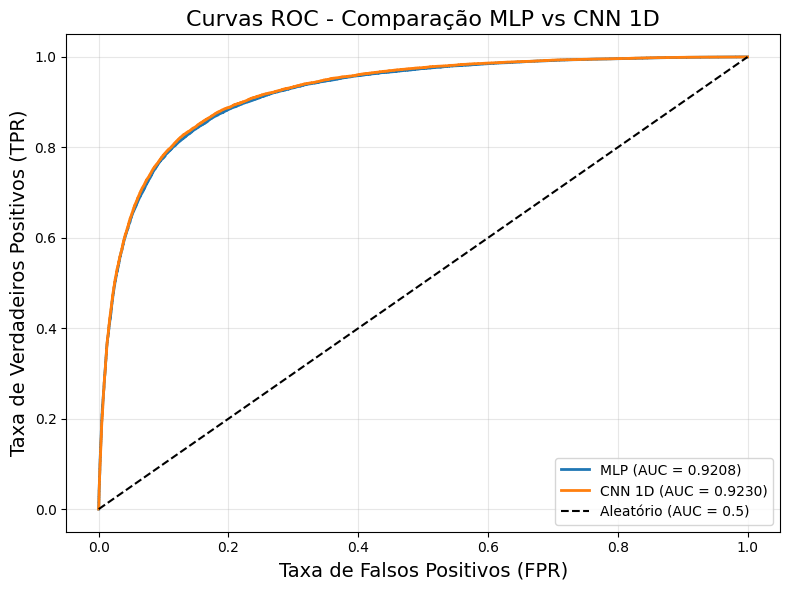

AUC da MLP: 0.9208
AUC da CNN 1D: 0.9230


In [19]:
y_pred_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_cnn = cnn_model.predict(X_test_cnn).ravel()

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp)
auc_mlp = auc(fpr_mlp, tpr_mlp)

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc_mlp:.4f})', linewidth=2)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN 1D (AUC = {auc_cnn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC - Comparação MLP vs CNN 1D', fontsize=16)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=300)
plt.show()

print(f"AUC da MLP: {auc_mlp:.4f}")
print(f"AUC da CNN 1D: {auc_cnn:.4f}")

## Conclusão

Neste projeto, desenvolvemos e comparamos duas arquiteturas de redes neurais para a identificação de jatos de *bottom* (*b-tagging*), utilizando dados abertos do experimento CMS. Os modelos propostos foram:

- **MLP (Perceptron Multicamadas)**: com camadas densas e *dropout* para regularização.
- **CNN 1D (Rede Neural Convolucional Unidimensional)**: aplicando filtros convolucionais ao longo das 27 variáveis de entrada.

Ambos os modelos foram treinados com um conjunto de dados reduzido (2 arquivos de treino e 1 de teste) e apresentaram um desempenho excelente na tarefa de classificação binária (Hbb vs. QCD), com valores de AUC significativamente superiores ao classificador aleatório (AUC = 0,5).

### Comparação de Desempenho

- **AUC da MLP**: 0,9208
- **AUC da CNN 1D**: 0,9230

A CNN 1D obteve uma AUC ligeiramente superior (cerca de 0,2% maior) em comparação com a MLP. Embora essa diferença seja modesta, ela sugere que a arquitetura convolucional conseguiu explorar correlações locais entre *features* adjacentes, capturando padrões que a MLP, por tratar todas as entradas de forma independente, não conseguiu extrair com a mesma eficácia.

No entanto, o desempenho extremamente próximo entre os dois modelos também reforça a qualidade das variáveis físicas disponibilizadas pelo CMS — que já são altamente discriminantes — permitindo que mesmo um modelo denso simples alcance resultados muito satisfatórios.

### Implicações e Como Melhorar o desempenho (próximos passo/outro projeto)

Para aplicações práticas em física de partículas, a escolha entre MLP e CNN deve levar em conta o custo computacional e a disponibilidade de recursos:
- A **MLP** é computacionalmente mais leve, de treinamento mais rápido e mais fácil de implementar, sendo ideal para *baselines* ou cenários com restrições de *hardware*.
- A **CNN 1D**, por outro lado, oferece uma margem de melhora no poder preditivo que pode ser relevante em análises de alta precisão, especialmente se expandida com mais camadas ou treinada com conjuntos de dados maiores.

Como próximos passos, seria interessante explorar arquiteturas mais complexas (como redes residuais ou *Transformers*) e realizar uma busca sistemática de hiperparâmetros para avaliar se a vantagem da CNN pode ser ampliada. Além disso, a aplicação de técnicas de *data augmentation* e a utilização de todos os arquivos disponíveis no *Open Data* poderiam elevar ainda mais a acurácia dos modelos.

Em suma, este estudo demonstrou que ambas as abordagens de aprendizado profundo são ferramentas poderosas para o *b-tagging* em dados do LHC, com a CNN 1D apresentando uma vantagem marginal que a torna uma escolha atraente para cenários onde o melhor desempenho possível é crítico.

### Resumo

#### Este notebook demonstrou o pipeline completo para:
- 1. Download dos dados do CMS Open Data.
- 2. Preparação e pré-processamento.
- 3. Construção e treinamento de dois modelos de deep learning (MLP e CNN 1D).
- 4. Comparação objetiva via curva ROC e AUC. 

#### Os resultados obtidos podem ser utilizados como base para otimizações futuras, como ajuste de hiperparâmetros, arquiteturas mais complexas ou uso de representações alternativas dos jatos (ex: imagens).
